# سوال اول - بخش سوم: پیاده‌سازی و تحلیل تجربی

## مرحله ۰ - بازتولیدپذیری

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

np.random.seed(42)

data = pd.read_csv("compas-scores-two-years.csv")

data = data[(data["days_b_screening_arrest"] >= -30) & (data["days_b_screening_arrest"] <= 30)]

cols = ["age", "c_charge_degree", "race", "sex", "priors_count", "days_b_screening_arrest", "decile_score", "two_year_recid"]
data = data[cols].dropna()

train, test = train_test_split(
    data, 
    test_size = 0.2, 
    stratify = data["two_year_recid"], 
    random_state = 42
)

print(f"Training data size: {len(train)}")
print(f"Testing data size: {len(test)}")
print(f"Train/Test Split: {len(train)/len(data):.0%} / {len(test)/len(data):.0%}")

Training data size: 4937
Testing data size: 1235
Train/Test Split: 80% / 20%


## مرحله ۱ - ممیزی سوگیری

Base Rates (P(Y=1)) by Race:
race
African-American    0.522494
Native American     0.500000
Caucasian           0.394391
Other               0.381295
Hispanic            0.346988
Asian               0.291667
Name: two_year_recid, dtype: float64 



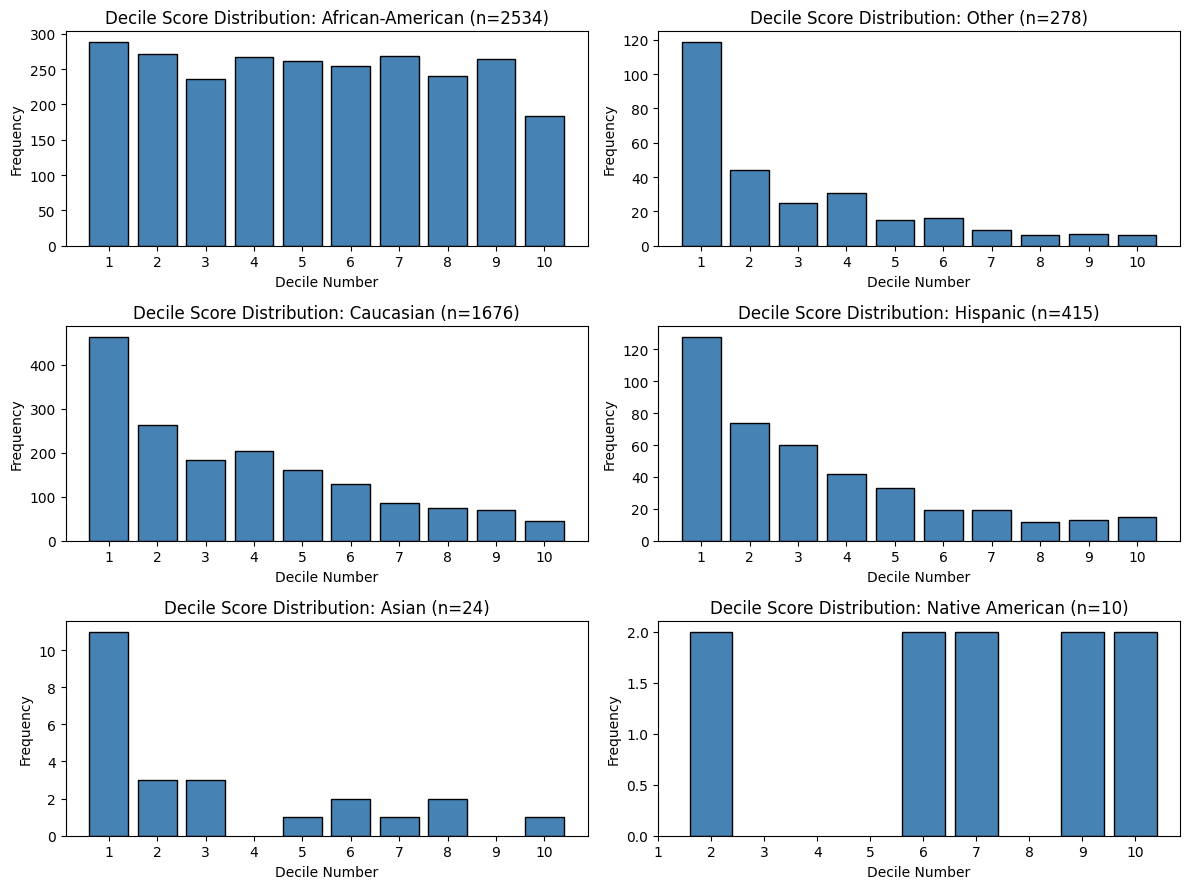

Proxy Strength for race:
decile_score               0.307519
priors_count               0.206501
age                        0.182453
c_charge_degree_F          0.112479
c_charge_degree_M          0.112479
sex_Male                   0.082964
sex_Female                 0.082964
days_b_screening_arrest    0.078932
dtype: float64


In [89]:
# الف
base_rates = train.groupby("race")["two_year_recid"].mean().sort_values(ascending=False)
print("Base Rates (P(Y=1)) by Race:")
print(base_rates, "\n")

# ب
unique_races = train["race"].unique()
races_num = len(unique_races)
cols_layout = 2
rows_layout = (races_num) // 2

fig, axes = plt.subplots(rows_layout, cols_layout, figsize=(12, 3 * rows_layout))
axes = axes.flatten()

for i, r in enumerate(unique_races):
    subset = train[train["race"] == r]
    counts = subset["decile_score"].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color = "steelblue", edgecolor = "black")
    axes[i].set_title(f"Decile Score Distribution: {r} (n={len(subset)})")
    axes[i].set_xlabel("Decile Number")
    axes[i].set_ylabel("Frequency")
    axes[i].set_xticks(range(1, 11))
    
plt.tight_layout()
plt.show()

# ج
encoded_data = pd.get_dummies(train.drop(columns=["two_year_recid"]))

corr_matrix = encoded_data.corr().abs()

race_cols = [col for col in encoded_data.columns if "race_" in col]
non_race_cols = [col for col in encoded_data.columns if "race_" not in col]

proxy_strength = corr_matrix.loc[non_race_cols, race_cols].max(axis=1).sort_values(ascending=False)

print("Proxy Strength for race:")
print(proxy_strength)

## مرحله ۲ - مدل پایه و سنجه‌های دست‌ساز

In [90]:
cols_to_drop = ["two_year_recid", "decile_score"]

X_train = pd.get_dummies(train.drop(columns=cols_to_drop), drop_first=True)
y_train = train["two_year_recid"]

X_test = pd.get_dummies(test.drop(columns=cols_to_drop), drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test["two_year_recid"]


# الف
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("----- Baseline Model Performance -----")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}\n")

# ب و ج
results_data = test.copy()
results_data["y_true"] = y_test
results_data["y_pred"] = y_pred

def calculate_metrics(group):
    y_t = group["y_true"]
    y_p = group["y_pred"]
    
    TP = ((y_t == 1) & (y_p == 1)).sum()
    FP = ((y_t == 0) & (y_p == 1)).sum()
    TN = ((y_t == 0) & (y_p == 0)).sum()
    FN = ((y_t == 1) & (y_p == 0)).sum()
    
    dp = y_p.mean() 
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    return pd.Series({"Demographic Parity": dp, "TPR": tpr, "FPR": fpr, "PPV": ppv})

group_metrics = results_data.groupby("race").apply(calculate_metrics)

aa_metrics = group_metrics.loc["African-American"]
cc_metrics = group_metrics.loc["Caucasian"]

gaps = pd.Series({
    "Demographic Parity Gap": abs(aa_metrics["Demographic Parity"] - cc_metrics["Demographic Parity"]),
    "TPR Gap": abs(aa_metrics["TPR"] - cc_metrics["TPR"]),
    "FPR Gap": abs(aa_metrics["FPR"] - cc_metrics["FPR"]),
    "PPV Gap": abs(aa_metrics["PPV"] - cc_metrics["PPV"])
})

print("----- Metrics by Group -----")
print(group_metrics.round(4), "\n")

print("----- Inter-Group Gaps (African-American vs Caucasian) -----")
print(gaps.round(4), "\n")

----- Baseline Model Performance -----
Accuracy: 0.6826
ROC-AUC: 0.7272

----- Metrics by Group -----
                  Demographic Parity     TPR     FPR     PPV
race                                                        
African-American              0.5164  0.6884  0.3257  0.7009
Asian                         0.0000  0.0000  0.0000  0.0000
Caucasian                     0.2365  0.3975  0.1391  0.6337
Hispanic                      0.2128  0.3111  0.1224  0.7000
Native American               1.0000  0.0000  1.0000  0.0000
Other                         0.1077  0.2778  0.0426  0.7143 

----- Inter-Group Gaps (African-American vs Caucasian) -----
Demographic Parity Gap    0.2798
TPR Gap                   0.2909
FPR Gap                   0.1866
PPV Gap                   0.0672
dtype: float64 



C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\3123180882.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_metrics = results_data.groupby("race").apply(calculate_metrics)


## مرحله ۳ - آزمون انصاف از طریق ناآگاهی

In [91]:
race_columns = [col for col in X_train.columns if "race_" in col]

X_train_unaware = X_train.drop(columns=race_columns)
X_test_unaware = X_test.drop(columns=race_columns)

model_unaware = LogisticRegression(max_iter=1000, random_state=42)
model_unaware.fit(X_train_unaware, y_train)

y_pred_unaware = model_unaware.predict(X_test_unaware)

results_unaware = test.copy()
results_unaware["y_true"] = y_test
results_unaware["y_pred"] = y_pred_unaware

group_metrics_unaware = results_unaware.groupby("race").apply(calculate_metrics)

aa_metrics_un = group_metrics_unaware.loc["African-American"]
cc_metrics_un = group_metrics_unaware.loc["Caucasian"]

gaps_unaware = pd.Series({
    "Demographic Parity Gap": abs(aa_metrics_un["Demographic Parity"] - cc_metrics_un["Demographic Parity"]),
    "TPR Gap": abs(aa_metrics_un["TPR"] - cc_metrics_un["TPR"]),
    "FPR Gap": abs(aa_metrics_un["FPR"] - cc_metrics_un["FPR"]),
    "PPV Gap": abs(aa_metrics_un["PPV"] - cc_metrics_un["PPV"])
})

print("\n----- Metrics by Group (Unaware Model) -----")
print(group_metrics_unaware.round(4))

print("\n----- Inter-Group Gaps (African-American vs Caucasian) -----")
print(gaps_unaware.round(4))


----- Metrics by Group (Unaware Model) -----
                  Demographic Parity     TPR     FPR     PPV
race                                                        
African-American              0.4867  0.6588  0.2961  0.7115
Asian                         0.1429  1.0000  0.0000  1.0000
Caucasian                     0.2342  0.3913  0.1391  0.6300
Hispanic                      0.2872  0.3778  0.2041  0.6296
Native American               1.0000  0.0000  1.0000  0.0000
Other                         0.2154  0.4444  0.1277  0.5714

----- Inter-Group Gaps (African-American vs Caucasian) -----
Demographic Parity Gap    0.2525
TPR Gap                   0.2674
FPR Gap                   0.1570
PPV Gap                   0.0815
dtype: float64


C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\2695000871.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_metrics_unaware = results_unaware.groupby("race").apply(calculate_metrics)


## مرحله ۴ - تعدیل و مقایسه

In [93]:
in_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints=DemographicParity()
)
in_model.fit(X_train, y_train, sensitive_features=train["race"])
y_pred_in = in_model.predict(X_test)

post_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints="equalized_odds",
    predict_method="auto"
)
post_model.fit(X_train, y_train, sensitive_features=train["race"])
y_pred_post = post_model.predict(X_test, sensitive_features=test["race"])


def get_metrics_and_gaps(y_predicted, model_name):
    result_data = test.copy()
    result_data["y_true"] = y_test
    result_data["y_pred"] = y_predicted
    
    acc = accuracy_score(y_test, y_predicted)
    
    metrics = result_data.groupby("race").apply(calculate_metrics)
    
    aa_metrics = metrics.loc["African-American"]
    cc_metrics = metrics.loc["Caucasian"]
    
    gaps = {
        "Accuracy": acc,
        "Dem Parity Gap": abs(aa_metrics["Demographic Parity"] - cc_metrics["Demographic Parity"]),
        "TPR Gap": abs(aa_metrics["TPR"] - cc_metrics["TPR"]),
        "FPR Gap": abs(aa_metrics["FPR"] - cc_metrics["FPR"]),
        "PPV Gap": abs(aa_metrics["PPV"] - cc_metrics["PPV"])
    }
    
    return metrics, pd.Series(gaps, name=model_name)

metrics_base, gaps_base = get_metrics_and_gaps(y_pred, "Baseline")
metrics_in, gaps_in = get_metrics_and_gaps(y_pred_in, "Exponentiated Gradient")
metrics_post, gaps_post = get_metrics_and_gaps(y_pred_post, "Threshold optimization")

print("----- Base Model Metrics -----")
print(metrics_base.round(4), "\n")

print("----- In-Processing Metrics (Exponentiated Gradient) -----")
print(metrics_in.round(4), "\n")

print("----- Post-Processing Metrics (Threshold optimization) -----")
print(metrics_post.round(4), "\n")

print("----- Final Comparison Table (Gaps: African-American vs Caucasian) -----")
comparison_table = pd.concat([gaps_base, gaps_in, gaps_post], axis=1).round(4)
print(comparison_table)

----- Base Model Metrics -----
                  Demographic Parity     TPR     FPR     PPV
race                                                        
African-American              0.5164  0.6884  0.3257  0.7009
Asian                         0.0000  0.0000  0.0000  0.0000
Caucasian                     0.2365  0.3975  0.1391  0.6337
Hispanic                      0.2128  0.3111  0.1224  0.7000
Native American               1.0000  0.0000  1.0000  0.0000
Other                         0.1077  0.2778  0.0426  0.7143 

----- In-Processing Metrics (Exponentiated Gradient) -----
                  Demographic Parity     TPR     FPR     PPV
race                                                        
African-American              0.3697  0.5401  0.1809  0.7679
Asian                         0.2857  0.0000  0.3333  0.0000
Caucasian                     0.3372  0.5031  0.2368  0.5625
Hispanic                      0.3511  0.4222  0.2857  0.5758
Native American               0.0000  0.0000  0.0000  

C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\4079986132.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = result_data.groupby("race").apply(calculate_metrics)
C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\4079986132.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = result_data.groupby("race").apply(calculate_metrics)
C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\4079986132.py

## مرحله ۵ - عدم امکان تجربی و مرز بده‌بستان

C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\358614733.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  new_metrics = result_sweep.groupby("race").apply(calculate_metrics)
C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\358614733.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  new_metrics = result_sweep.groupby("race").apply(calculate_metrics)
C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\35861

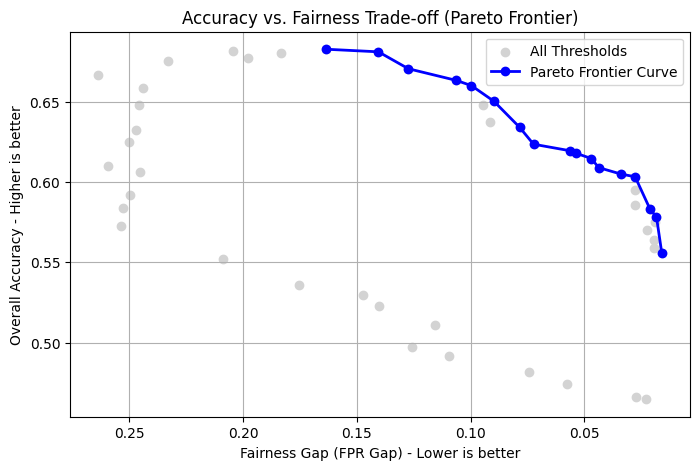

In [94]:
# الف
thresholds = np.linspace(0.1, 0.9, 50)
accuracies = []
fpr_gaps = []

y_prob = model.predict_proba(X_test)[:, 1]
result_sweep = test.copy()
result_sweep["y_true"] = y_test

for thresh in thresholds:
    result_sweep["y_pred"] = (y_prob >= thresh).astype(int)
    
    acc = accuracy_score(y_test, result_sweep["y_pred"])
    accuracies.append(acc)
    
    new_metrics = result_sweep.groupby("race").apply(calculate_metrics)
    
    aa_fpr = new_metrics.loc["African-American", "FPR"]
    cc_fpr = new_metrics.loc["Caucasian", "FPR"]
    fpr_gaps.append(abs(aa_fpr - cc_fpr))


valid_points = [(g, a) for g, a in zip(fpr_gaps, accuracies) if not np.isnan(g)]
sorted_points = sorted(valid_points, key=lambda x: x[0])

pareto_x = []
pareto_y = []
max_acc = -np.inf

for gap, acc in sorted_points:
    if acc > max_acc:
        pareto_x.append(gap)
        pareto_y.append(acc)
        max_acc = acc

plt.figure(figsize=(8, 5))

all_x = [p[0] for p in valid_points]
all_y = [p[1] for p in valid_points]
plt.scatter(all_x, all_y, color="lightgray", label="All Thresholds")

plt.plot(pareto_x, pareto_y, marker="o", color="blue", linewidth=2, label="Pareto Frontier Curve")

plt.title("Accuracy vs. Fairness Trade-off (Pareto Frontier)")
plt.xlabel("Fairness Gap (FPR Gap) - Lower is better")
plt.ylabel("Overall Accuracy - Higher is better")

plt.gca().invert_xaxis() 

plt.legend()
plt.grid(True)
plt.show()

In [95]:
# ب
result_imp = test.copy()
result_imp["y_true"] = y_test
result_imp["y_pred"] = (y_prob >= 0.5).astype(int)

def verify_impossibility(group_name):
    group_data = result_imp[result_imp["race"] == group_name]
    y_t = group_data["y_true"]
    y_p = group_data["y_pred"]
    
    p = y_t.mean()
    
    TP = ((y_t == 1) & (y_p == 1)).sum()
    FP = ((y_t == 0) & (y_p == 1)).sum()
    TN = ((y_t == 0) & (y_p == 0)).sum()
    FN = ((y_t == 1) & (y_p == 0)).sum()
    
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FNR = 1 - TPR
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    LHS = FPR
    
    term1 = p / (1 - p)
    term2 = (1 - PPV) / PPV if PPV > 0 else 0
    term3 = (1 - FNR)
    RHS = term1 * term2 * term3
    
    print(f"----- Race: {group_name} -----")
    print(f"Base Rate (p): {p:.4f}")
    print(f"LHS (Actual FPR): {LHS:.4f}")
    print(f"RHS (Calculated): {RHS:.4f}")
    print(f"Difference: {abs(LHS - RHS):.4f}\n")

verify_impossibility("African-American")
verify_impossibility("Caucasian")

----- Race: African-American -----
Base Rate (p): 0.5257
LHS (Actual FPR): 0.3257
RHS (Calculated): 0.3257
Difference: 0.0000

----- Race: Caucasian -----
Base Rate (p): 0.3770
LHS (Actual FPR): 0.1391
RHS (Calculated): 0.1391
Difference: 0.0000



## مرحله ۶ - ممیزی قطعی

In [96]:
result_inter = test.copy()
result_inter['y_true'] = y_test

result_inter['y_pred'] = y_pred_in 

result_inter['race_sex'] = result_inter['race'] + " - " + result_inter['sex']

inter_metrics = result_inter.groupby('race_sex').apply(calculate_metrics)

print("----- All Intersectional Subgroups -----")
print(inter_metrics.round(4))

main_inter = [
    'African-American - Male', 
    'African-American - Female',
    'Caucasian - Male', 
    'Caucasian - Female'
]

inter_metrics_main = inter_metrics.loc[inter_metrics.index.isin(main_inter)]

print("\n----- Intersectional Subgroups in African-American & Caucasian -----")
print(inter_metrics_main.round(4)) 

----- All Intersectional Subgroups -----
                           Demographic Parity     TPR     FPR     PPV
race_sex                                                             
African-American - Female              0.1466  0.3023  0.0548  0.7647
African-American - Male                0.4190  0.5748  0.2208  0.7682
Asian - Male                           0.2857  0.0000  0.3333  0.0000
Caucasian - Female                     0.1163  0.2500  0.0370  0.8000
Caucasian - Male                       0.3930  0.5659  0.2877  0.5448
Hispanic - Female                      0.1111  0.1000  0.1250  0.5000
Hispanic - Male                        0.4079  0.5143  0.3171  0.5806
Native American - Male                 0.0000  0.0000  0.0000  0.0000
Other - Female                         0.0000  0.0000  0.0000  0.0000
Other - Male                           0.3077  0.5000  0.2059  0.5625

----- Intersectional Subgroups in African-American & Caucasian -----
                           Demographic Parity    

C:\Users\Mjavad\AppData\Local\Temp\ipykernel_14288\1346455011.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inter_metrics = result_inter.groupby('race_sex').apply(calculate_metrics)
